In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
import scipy.stats as sps
import random
import copy

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import f1_score

from tqdm import tqdm

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
links = pd.read_csv('archive/link.csv')
movies = pd.read_csv('archive/movie.csv')
ratings = pd.read_csv('archive/rating.csv')
#tags = pd.read_csv('/content/tags.csv')

In [4]:
ratings = ratings.iloc[0:len(ratings)//1000]

data = pd.merge(ratings, movies, on='movieId', how='left')
data = data[['userId', 'movieId', 'rating', 'genres', 'timestamp']]
data['genres'] = data['genres'].str.split('|')


mlb = MultiLabelBinarizer()
genre_features = pd.DataFrame(mlb.fit_transform(data['genres']), columns=mlb.classes_)

data = pd.concat([data, genre_features], axis=1)
genre_columns = set(data.columns) - set(['userId', 'movieId',
                                         'genres', 'rating', 'timestamp'])
data.head(4)

,userId,movieId,rating,genres,timestamp,Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,2,3.5,"[Adventure, Children, Fantasy]",2005-04-02 23:53:47,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,29,3.5,"[Adventure, Drama, Fantasy, Mystery, Sci-Fi]",2005-04-02 23:31:16,0,1,0,0,0,...,0,0,0,0,1,0,1,0,0,0
2,1,32,3.5,"[Mystery, Sci-Fi, Thriller]",2005-04-02 23:33:39,0,0,0,0,0,...,0,0,0,0,1,0,1,1,0,0
3,1,47,3.5,"[Mystery, Thriller]",2005-04-02 23:32:07,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


In [5]:
data['userId'] = data['userId'].astype('category').cat.codes
data['movieId'] = data['movieId'].astype('category').cat.codes

# Нормализуем рейтинги
scaler = MinMaxScaler(feature_range=(0, 1))

data['rating'] = scaler.fit_transform(data[['rating']])
data['rating_label'] = (data['rating'] >= 0.7).astype('int')

In [6]:
data['rating_label'].describe()

count    20000.000000
mean         0.485000
std          0.499787
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: rating_label, dtype: float64

### Делаем эмбеддинги

In [7]:
class RecDataset(Dataset):
    def __init__(self, data):
        self.users = torch.tensor(data['userId'].values, dtype=torch.long)
        self.movies = torch.tensor(data['movieId'].values, dtype=torch.long)
        self.ratings = torch.tensor(data['rating_label'].values, dtype=torch.float32)
        self.genres = torch.tensor(data[list(genre_columns)].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.genres[idx], self.ratings[idx]


In [8]:
class TrainEmbModel(nn.Module):
    def __init__(self,
                 num_users,
                 num_items,
                 num_genres,
                 embedding_user_dim,
                 embedding_item_dim,
                 extra_param_embedding_dim,
                 hidden_size=25):

        super(TrainEmbModel, self).__init__()
        self.user_embedding = nn.Embedding(num_users, embedding_user_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_item_dim)
        self.genre_fc = nn.Linear(num_genres, extra_param_embedding_dim)

        self.fc1 = nn.Linear(embedding_item_dim + embedding_user_dim +
                             extra_param_embedding_dim, hidden_size)

        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1) #т.к. решаем задачу бинарной классификации
        self.sigmoid = nn.Sigmoid()


    def forward(self, user_ids, item_ids, genre_vectors):
        user_emb = self.user_embedding(user_ids)
        item_emb = self.item_embedding(item_ids)
        genre_emb = self.genre_fc(genre_vectors)

        nn_input = torch.cat([user_emb, item_emb, genre_emb], dim=1)

        fc1_output = self.fc1(nn_input)
        fc2_output = self.fc2(self.relu(fc1_output))
        return self.sigmoid(fc2_output)


In [9]:
train, test = train_test_split(data, test_size=0.2)
train_dataset = RecDataset(train)
test_dataset = RecDataset(test)
batch_size = 128

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                            shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                            shuffle=False, num_workers=0)

In [10]:
params = {'num_users' : len(data['userId'].unique()),
'num_items' : len(data['movieId'].unique()),
'num_genres' : len(genre_columns),
'embedding_user_dim' : 10,
'embedding_item_dim' : 10,
'extra_param_embedding_dim' : 10}


model = TrainEmbModel(**params).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.005)
criterion = nn.BCELoss()

In [11]:
for epoch in range(1):
    model.train()
    for user_ids, movie_ids, genres, ratings in train_loader:
        user_ids = user_ids.to(device)
        movie_ids = movie_ids.to(device)
        genres = genres.to(device)
        ratings = ratings.to(device)
        optimizer.zero_grad()
        predictions = model(user_ids, movie_ids, genres)
        loss = criterion(predictions.squeeze(), ratings)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.6952004432678223


In [12]:
train_dataset[0]

(tensor(53),
 tensor(1221),
 tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.,
         0.]),
 tensor(0.))

In [13]:
users_embedding_0 = model.user_embedding(torch.tensor(list(np.sort(data['userId'].unique())),
                                                      dtype=torch.long).to(device))
users_embedding_0.shape

torch.Size([156, 10])

In [14]:
movies['genres']

0        Adventure|Animation|Children|Comedy|Fantasy
1                         Adventure|Children|Fantasy
2                                     Comedy|Romance
3                               Comedy|Drama|Romance
4                                             Comedy
                            ...                     
27273                                         Comedy
27274                                         Comedy
27275                                      Adventure
27276                             (no genres listed)
27277                       Adventure|Fantasy|Horror
Name: genres, Length: 27278, dtype: object

In [15]:
movies['genres'] = movies['genres'].str.split('|')
genre_to_movies = pd.DataFrame(mlb.transform(movies['genres']), columns=mlb.classes_)

genre_to_movies

/Users/sdem3/miniconda3/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['(no genres listed)'] will be ignored
  warnings.warn(


,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27273,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
27274,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
27275,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
27276,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### Смотрим на распределение Эмбеддингов

In [16]:
df = data.copy(deep=True)
df = df.sort_values(by=['userId'])

# Создаем столбец 'wasnot_later'
df['wasnot_later'] = (df.groupby(['movieId']).cumcount() == 0).astype(int)

df = df[df['wasnot_later'] == 1]
movie_emb = model.item_embedding( torch.tensor(list(df['movieId'].values), dtype=torch.long ).to(device) )

genre_emb = model.genre_fc(torch.tensor(df[list(genre_columns)].values, dtype=torch.float32).to(device) )

item_embedding_0 = torch.cat([movie_emb, genre_emb], dim=1)
item_embedding_0.shape


torch.Size([4192, 20])

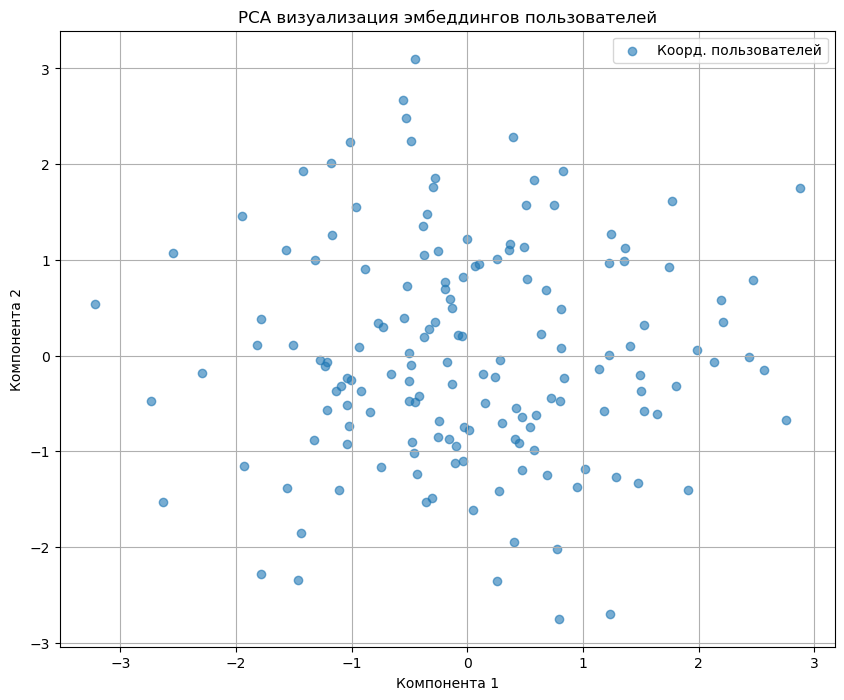

In [17]:
tsne = PCA(n_components=2)
embeddings_2d = tsne.fit_transform(users_embedding_0.detach().cpu().numpy())
mean_hat = np.mean(users_embedding_0.detach().cpu().numpy(), axis=0)
cov_hat = np.cov(users_embedding_0.detach().cpu().numpy(), rowvar=False)

# Визуализация
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            alpha=0.6, label='Коорд. пользователей')

plt.title("PCA визуализация эмбеддингов пользователей")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from statsmodels.stats.multitest import multipletests
alpha = 0.05
pvalues = []
for i in range(users_embedding_0.detach().cpu().numpy().shape[1]):
    statistic, p_value = sps.kstest(users_embedding_0.detach().cpu().numpy()[:, i],
                                'norm', args=(mean_hat[i], np.sqrt(cov_hat[i, i])))
    pvalues.append(p_value)

reject, p_corrected, _, _ = multipletests(pvalues, method='fdr_bh')
print("Скорректированные p-значения (Бенджамини-Хохберг):", p_corrected)

Скорректированные p-значения (Бенджамини-Хохберг): [0.99894891 0.99894891 0.99894891 0.99894891 0.99894891 0.99894891
 0.99894891 0.99894891 0.99894891 0.99894891]


Данные с очень большой вероятностью – НОРМАЛЬНЫЕ!

In [19]:
'''
  tsne = TSNE(n_components=2, random_state=42)
  embeddings_2d = tsne.fit_transform(item_embedding_0.detach().cpu().numpy())

  # Визуализация
  plt.figure(figsize=(10, 8))
  plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
  plt.title("t-SNE визуализация эмбеддингов фильмов")
  plt.xlabel("Компонента 1")
  plt.ylabel("Компонента 2")
  plt.grid(True)
  plt.show()
'''

'\n  tsne = TSNE(n_components=2, random_state=42)\n  embeddings_2d = tsne.fit_transform(item_embedding_0.detach().cpu().numpy())\n\n  # Визуализация\n  plt.figure(figsize=(10, 8))\n  plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)\n  plt.title("t-SNE визуализация эмбеддингов фильмов")\n  plt.xlabel("Компонента 1")\n  plt.ylabel("Компонента 2")\n  plt.grid(True)\n  plt.show()\n'

Опишем эксперимент более подробно:

У нас есть 4 алгоритма, с возможностью изменения параметров в процессе обучения.


Считаем, что далее мы работаем с пользователями $u$ и товарами $i$ как с векторами из конечномерного линейного пространства. Эти эмбеддинги мы получили с помощью обучения алгоритма классификации и вычленили веса первого слоя.

\\


В каждый момент времени у нас есть $\mathcal{D}_t$ – датасет. Формально, он представляет из себя кортеж из трёх элементов: $\mathcal{D}_t = (U_t, I_t, M_t)$, где $U_t$ -- множество пользователей, находящихся в системе в данный момент времени. Аналогично $I_t$ – это множество товаров, находящихся в системе в данный момент времени. $M_t$ – это, неформально, матрица размерности $\mathbb{R}^{|U_t| \times |I_t|}$, где $\big(M_t\big)_{ij} = \text{оценка пользователя } U_i \text{ на  товар } I_j$

\\


$a_{rec}$ – алгоритм рекомендаций.

$a_{choice}$ – алгоритм выбора пользователем товаров

$itemGAN$ – алгоритм, который в момент времени t возвращает все товары, которые будут на шаге ${t+1}$ (т.е. модифицирует массив всех товаров с шага $t$, добавляя в него как новые товары, так и удаляя старые товары)

$userGAN$ – алгоритм, который в момент времени t возвращает массив пользователей, которые будут на шаге ${t+1}$. Аналогично $itemGAN$


 \\

****
Говоряя более подробно о сути этих алгоритмов, как отображений:

1) $a_{rec} : U \times I \rightarrow [0; 1]$

2) $a_{choice} : U \times I^K \rightarrow 2^{\{1, 2, \ldots K\}}$

3) $itemGAN: (I_t, M_t) \mapsto (I_{t+1}, M_{t+1})$

4) $userGAN : (U_t, M_t) \mapsto (U_{t+1}, M_{t+1})$



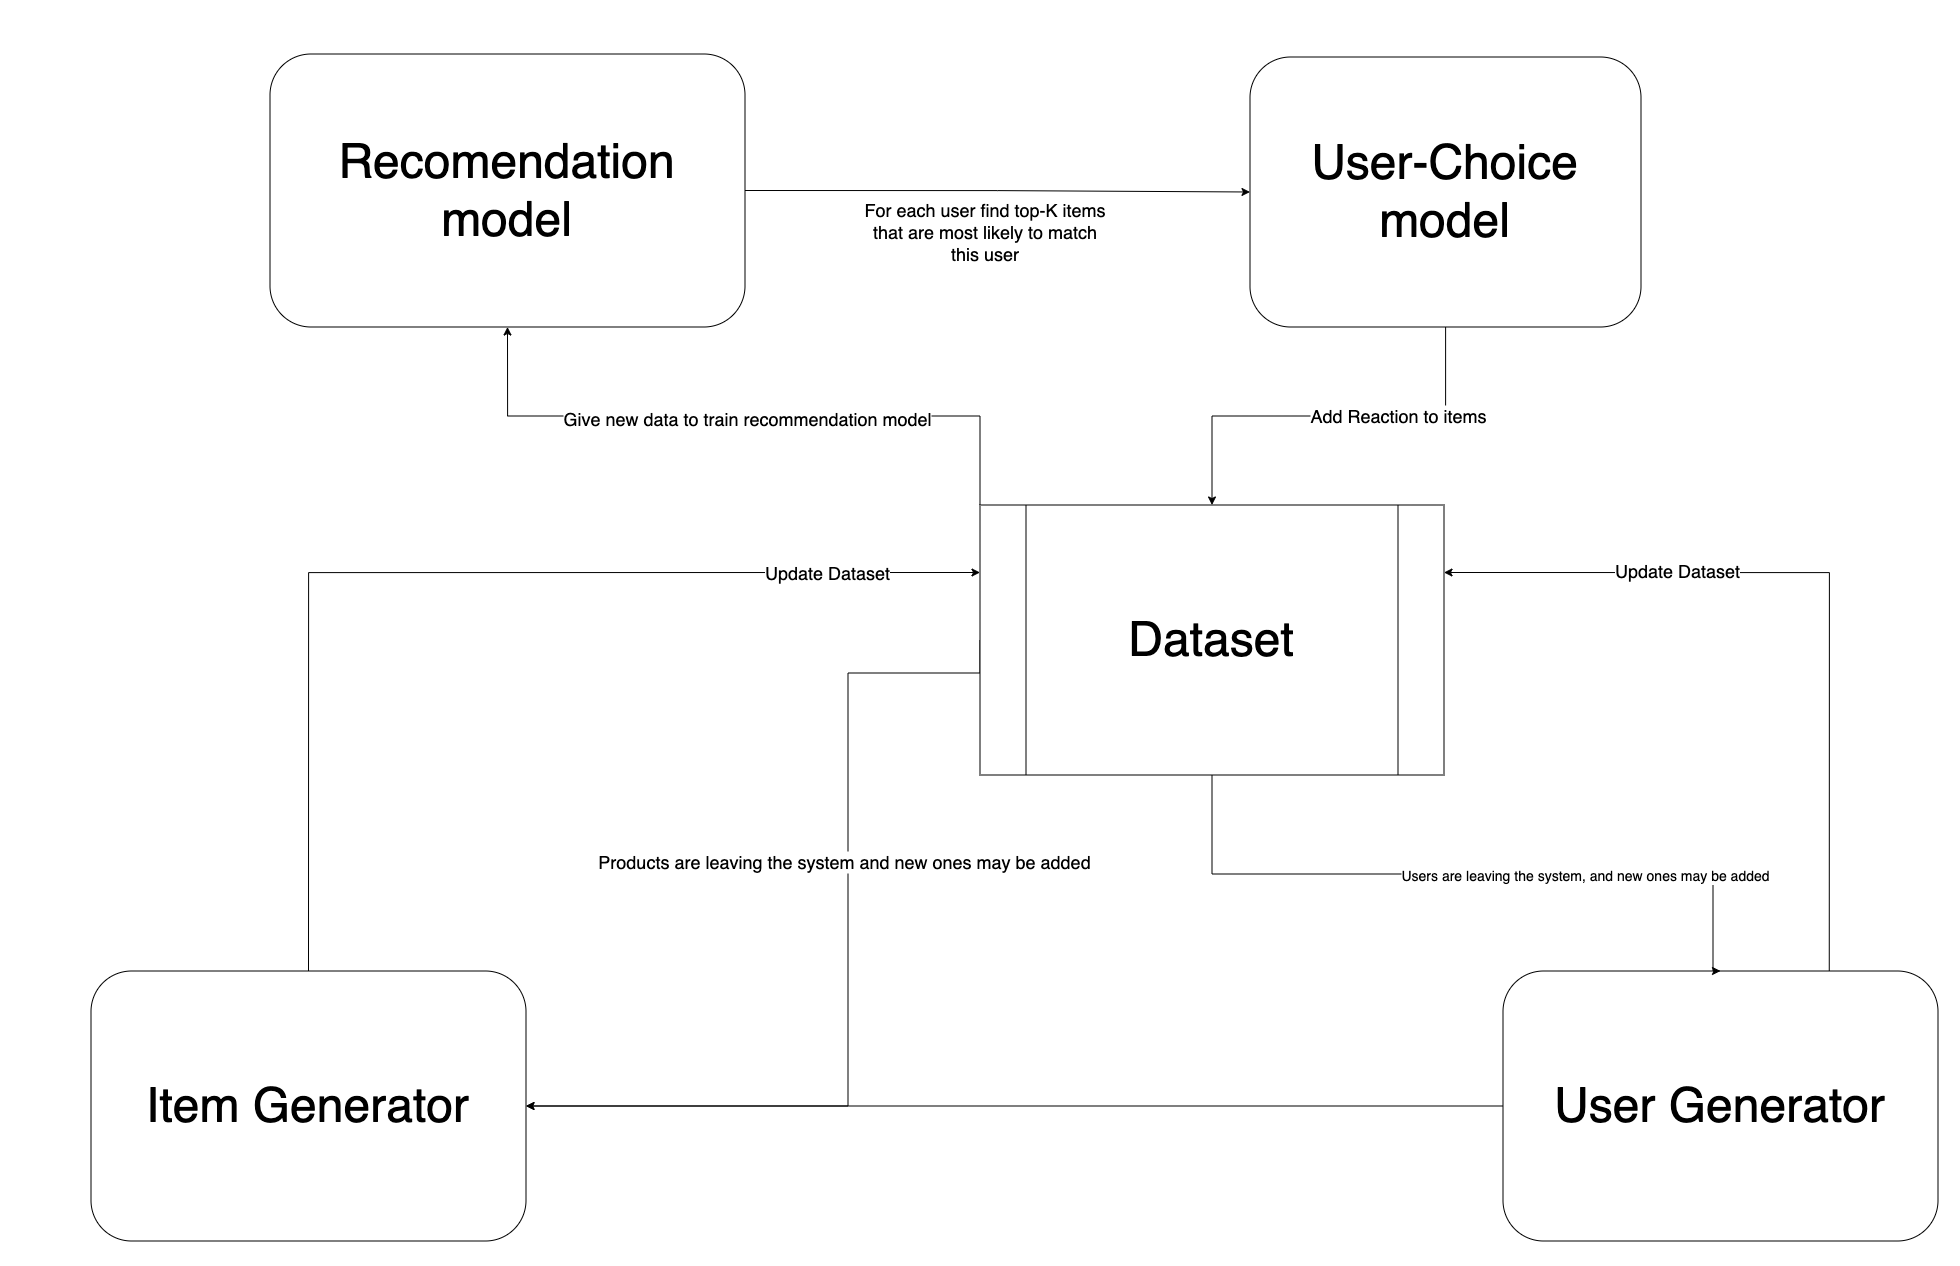

**При этом, в качестве реализаций этих алгоритмов мы будем использовать нейронные сети.**


$a_{rec}$ – нейронная сеть, обучающаяся предсказывать 0/1 – понравится ли конкретный айтем $i$ пользователю $u$. Использует $BCE-Loss$ и содержит два полносвязных слоя с функцией активацией $ReLU$

\\

$a_{choice}$ – неройнная сеть, которая обучается предсказывать по входу: $(u, (i_1, \ldots i_K))$ вектор размерности $K$, где единица на $l$-ой позиции будет означать, что пользователь выбрал айтем $i_l$. Эта модель решает задачу мультиклассовой классификации (multi-label classification). Для решения этой задачи мы тоже используем $BCE-Loss$, а также двухслойную-полносвязную нейронную сеть.

\\


Перед тем как окончательно решить, что в рамках этой задачи можно использовать как векторное представление (т.е. эмбеддинги) веса одной предварительно обученной сети, мы рассмотрели распределение этих векторов-эмбеддингов. Получилось что эти вектора из нормального распределения. Что подтверждается статистическими тестами. Тогда $itemGAN$ на шаге $t$ будет оценивать распределение параметров многомерного нормального распределения по массиву $U_t$ (т.е. массиву пользователей, находящихся в данный момент времени в системе) и уже семплировать из этого распределения нужно количество пользователей. Полностью аналогично работает и $userGAN$


### Определяем модели

#### Определяем структуры данных, которые будем использовать

Фильмы и пользователи до начала эксперимента закодированы их `id`,

 $\text{userId} \in [0; 609], \quad \text{movieId} \in [0; 9723]$

In [20]:
class ExperimentDataset():
    def __init__(self, user_embeddings, items_embeddings, rating_matrix):
        self.users_embeddings = user_embeddings
        self.items_embeddings = items_embeddings
        self.matrix = rating_matrix

    def update(self, new_users, new_items, new_ratings):
        self.user_embeddings = copy.deepcopy(new_users)
        self.items_embeddings = copy.deepcopy(new_items)
        self.matrix = copy.deepcopy(new_ratings)

    def update_ratings(self, interactions, t):
      '''
      Обновляет список взаимодействий между пользователем и фильмом

      :param interactions: список пользователей
      :type list:
      '''
      if len(interactions) >= 1:
        interactions = np.array(interactions)
        user_ids = interactions[:, 0]
        item_ids = interactions[:, 1]
        self.matrix[user_ids, item_ids] = t


In [21]:
class EfficientNaNUserBehaviorDataset(Dataset):
    def __init__(self, dataset, K, user_embedding_dim, item_embedding_dim):
        self.matrix = dataset.matrix
        self.dataset = dataset
        self.K = K

        # Предварительно вычисляем индексы не-NaN элементов для каждого пользователя
        self.user_watched = [np.where(~np.isnan(self.matrix[i]))[0]
                           for i in range(self.matrix.shape[0])]

        # Генерируем данные
        self.data = self._generate_data()

    def _generate_data(self):
        data = []
        for user_idx, watched in enumerate(self.user_watched):
            if len(watched) == 0:
                continue

            # Генерируем K случайных рекомендаций из просмотренных
            recs = np.random.choice(watched, size=min(self.K, len(watched)), replace=False)
            labels = (self.matrix[user_idx, recs] > 0.5).astype(float)
            data.append((user_idx, recs, labels))

        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        user_idx, recs, labels = self.data[idx]

        user = torch.FloatTensor(self.dataset.users_embeddings[user_idx])
        items = torch.FloatTensor(self.dataset.items_embeddings[recs])
        labels = torch.FloatTensor(labels)

        return user, items, labels

In [22]:
import scipy.sparse as sp

class OptimizedUserBehaviorDataset(Dataset):
    def __init__(self, dataset, K, user_embedding_dim, item_embedding_dim):
        # Преобразуем в CSR формат для эффективной работы с разреженными данными
        self.matrix = sp.csr_matrix(dataset.matrix)
        self.dataset = dataset
        self.K = K
        self.user_embedding_dim = user_embedding_dim
        self.item_embedding_dim = item_embedding_dim

        # Предварительно вычисляем непропущенные значения для каждого пользователя
        self.user_watched = [self.matrix.getrow(i).indices for i in range(self.matrix.shape[0])]

        # Генерируем данные один раз, без дублирования
        self.data = self._generate_optimized_data()

    def _generate_optimized_data(self):
        data = []
        for user_idx, watched in enumerate(self.user_watched):
            if len(watched) == 0:
                continue

            # Генерируем все возможные комбинации за один вызов
            all_recommendations = np.random.choice(
                watched,
                size=min(self.K * len(watched), len(watched)),
                replace=False
            )

            # Разбиваем на группы по K элементов
            for i in range(0, len(all_recommendations), self.K):
                recs = all_recommendations[i:i+self.K]
                labels = self.matrix[user_idx, recs].toarray().flatten()
                data.append((user_idx, recs, labels))

        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        user_idx, recommendations_indeces, labels = self.data[idx]

        # Используем заранее загруженные embedding'и
        user = torch.tensor(self.dataset.users_embeddings[user_idx], dtype=torch.float32)
        recommendations = torch.tensor(
            self.dataset.items_embeddings[recommendations_indeces],
            dtype=torch.float32
        )
        labels = torch.tensor(labels, dtype=torch.float32)

        return user, recommendations, labels

In [23]:
class UserBehaviorDataset(Dataset):
    def __init__(self, dataset, K, user_embedding_dim, item_embedding_dim):
        self.matrix = dataset.matrix.copy()
        self.dataset = dataset
        self.K = K
        self.users_count, self.items_count = self.matrix.shape
        self.data = self._generate_data()
        self.user_embedding_dim = user_embedding_dim
        self.item_embedding_dim = item_embedding_dim

    def _generate_data(self):
        data = []
        for user_idx in range(self.users_count):
            watched = np.where(~np.isnan(self.dataset.matrix[user_idx]))[0] #получаем номера столбцов с пропусками для user'a

            if len(watched) == 0:
                continue

            for _ in range(K * len(watched)):
                # Генерируем рекомендации (K фильмов, включая как понравившиеся, так и нет)
                size = min(len(watched), self.K)
                recommendations_indeces = np.random.choice(
                    watched,
                    size=size,
                    replace=False
                )

                labels = (self.matrix[user_idx, recommendations_indeces] > 0.1).astype(float)
                data.append((user_idx, recommendations_indeces, labels))

        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        user_idx, recommendations_indeces, labels = self.data[idx]

        user = self.dataset.users_embeddings[user_idx]
        recommendations = self.dataset.items_embeddings[recommendations_indeces]
        return torch.tensor(user, dtype=torch.float32), \
               torch.tensor(recommendations, dtype=torch.float32), \
               torch.tensor(labels, dtype=torch.float32)


In [24]:
class RecommendationDataset(Dataset):
    def __init__(self, dataset, user_embedding_dim, item_embedding_dim,
                 use_PCA=True, random_components=None):
        """
        Инициализация датасета.
        :param users_embeddings: Тензор эмбеддингов пользователей (num_users, embedding_dim).
        :param items_embeddings: Тензор эмбеддингов товаров (num_items, embedding_dim).
        :param matrix: Матрица мэтчей (num_users, num_items), где 1 — понравится, 0 — не понравится.
        :param use_PCA: логическая переменная, отвечающая за то, будем ли мы понижать размерность датасета с помощью PCA.
        :param random_components: iterable объект, который содержит индексы компонент исходного вектора, которые будут использоваться
                                  для обучения и инференса. Выглядит как (user_components, item_components)
        """
        self.users_embeddings = dataset.users_embeddings.copy()
        self.items_embeddings = dataset.items_embeddings.copy()
        self.matrix = dataset.matrix.copy()
        self.user_embedding_dim = user_embedding_dim
        self.item_embedding_dim = item_embedding_dim

        # Создаем список всех пар (пользователь, товар) и соответствующих меток
        self.pairs = []
        for user_id in range(dataset.matrix.shape[0]):
            for item_id in range(dataset.matrix.shape[1]):
                label = (dataset.matrix[user_id, item_id] > 0.1).astype(float)
                if not np.isnan(label):
                  self.pairs.append((user_id, item_id, label))

        #обрезаем датасет специально
        #size = len(self.pairs)
        #random.shuffle(self.pairs)
        #self.pairs = self.pairs[:size//3]

        #понижаем размерность
        if ((user_embedding_dim != users_embeddings.shape[1]) or
            (item_embedding_dim != items_embeddings.shape[1])):

            if use_PCA:
              user_transformer = PCA(n_components=user_embedding_dim)
              item_transformer = PCA(n_components=item_embedding_dim)

              self.users_embeddings = user_transformer.fit_transform(self.users_embeddings)
              self.items_embeddings = item_transformer.fit_transform(self.items_embeddings)
            elif random_components is not None:
              user_components, item_components = random_components
              self.users_embeddings = self.users_embeddings[:, user_components]
              self.items_embeddings = self.items_embeddings[:, item_components]

    def __len__(self):
        """Возвращает количество пар (пользователь, товар)."""
        return len(self.pairs)

    def __getitem__(self, idx):
        """
        Возвращает пару (пользователь, товар) и метку.
        :param idx: Индекс пары.
        :return: Эмбеддинг пользователя, эмбеддинг товара, метка.
        """
        user_id, item_id, label = self.pairs[idx]
        user_embedding = self.users_embeddings[user_id]
        item_embedding = self.items_embeddings[item_id]

        return torch.tensor(user_embedding, dtype=torch.float32), \
               torch.tensor(item_embedding, dtype=torch.float32), \
               torch.tensor(label, dtype=torch.float32)
    def get_with_id(self, idx):
      """
      Возвращает пару (пользователь, товар) и метку.
      :param idx: Индекс пары.
      :return: Эмбеддинг пользователя, эмбеддинг товара, метка.
      """
      user_id, item_id, label = self.pairs[idx]
      user_embedding = self.users_embeddings[user_id]
      item_embedding = self.items_embeddings[item_id]

      return torch.tensor(user_embedding, dtype=torch.float32), \
            torch.tensor(item_embedding, dtype=torch.float32), \
            torch.tensor(label, dtype=torch.float32), \
            user_id, item_id

#### Объявляем алгоритмы/модели

In [25]:
class RecModel(nn.Module): #по входу: (пользователь, товар) определяет есть ли мэтч
    def __init__(self,
                 embedding_user_dim,
                 embedding_item_dim,
                 hidden_size):

        super(RecModel, self).__init__()
        self.fc1 = nn.Linear(embedding_item_dim + embedding_user_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1) #т.к. решаем задачу бинарной классификации
        self.sigmoid = nn.Sigmoid()

    def forward(self, user, item):
        nn_input = torch.cat([user, item], dim=1)

        fc1_output = self.fc1(nn_input)
        fc2_output = self.fc2(self.relu(fc1_output))
        return self.sigmoid(fc2_output.squeeze(-1))

In [26]:
class ChoiceModel(nn.Module):
    def __init__(self,
                  embedding_user_dim,
                  embedding_item_dim,
                  K,
                  hidden_size
                  ):

          super(ChoiceModel, self).__init__()
          self.fc1 = nn.Linear(embedding_item_dim + embedding_user_dim, hidden_size)
          self.relu = nn.ReLU()
          self.fc2 = nn.Linear(hidden_size, 1) #решаем задачу multi-label классификации
          self.sigmoid = nn.Sigmoid()
          self.K = K

    def forward(self, user, items):
        user = user.unsqueeze(1).expand(-1, self.K, -1) #т.к. считаем что размерности идут в таком порядке:
                                                        # [batch_size, K, emb_size]
        nn_input = torch.cat([user, items], dim=2)
        fc1_output = self.fc1(nn_input)

        fc2_output = self.fc2(self.relu(fc1_output))
        fc2_output = fc2_output.squeeze(-1)
        return self.sigmoid(fc2_output.squeeze(-1))

In [27]:
class Generator():
  def __init__(self, embeddings, k, theta, emb_name, memory_effect=6, type_gen='User'):
    '''
    Конструктор для класса генератора пользователей
    :param embeddings: пользовательские эмбеддинги до начала эксперимента
    :type numpy array:

    :param k: коэффициент пропорциональности, который влияет на количество новых пользователей в системе
    :param theta: коэффициент, отвечающий за отношение ушедших пользователей к (пришедшим + ушедшим)
    '''
    self.embeddings = embeddings
    self.k = k
    self.theta = theta
    self.memory_effect = memory_effect
    self.distrib_params = {'mean' : np.mean(embeddings, axis=0),
                           'cov' : np.cov(embeddings, rowvar=False),
                           'allow_singular' : True}
    self.distrib_class = sps.multivariate_normal
    self.emb_name = emb_name
    self.type_gen = type_gen

  def update_params(self, dataset, deleted_indeces):
    '''
    Функция, которая обновляет параметры генератора
    в данном случае мы генерируем новых пользователей из нормального распределения,
    чьи параметры были получены на прошлом шаге.
    :param dataset: таблица со всеми сделками пользователей
    :param deleted_indeces: удаленные индексы, чтобы не учитывать ушедших пользователей,
                            при генерации новых
    '''
    embeddings_now = dataset.__getattribute__(self.emb_name)
    embeddings_without_deleted = np.delete(embeddings_now, deleted_indeces, axis=0)
    self.distrib_params = {'mean' : np.mean(embeddings_without_deleted, axis=0),
                           'cov' : np.cov(embeddings_without_deleted, rowvar=False),
                           'allow_singular' : True}


  def _get_deleted_indeces(self, deleted_count, dataset, time):
    axis_aggr = 1 if self.type_gen == 'User' else  0 #выбираем ось, по которой будет аггрегирование
    unsatisfied_indeces = np.argsort(np.nansum(dataset.matrix >= time - self.memory_effect, axis=axis_aggr))[0: deleted_count]
    return unsatisfied_indeces

  def _get_new(self, new_count, dataset, deleted_indeces):
    self.update_params(dataset, deleted_indeces)
    #print(self.distrib_params)
    return self.distrib_class(**self.distrib_params).rvs(new_count)


  def _generate_embeddings(self, dataset, time):
    #генерируем размеры выборок
    p = self.theta
    new_count = int(self.k * self.embeddings.shape[0])
    deleted_count = int(p / (1 - p) * new_count)

    #получаем индексы тех, кто покидает систему
    deleted_indeces = self._get_deleted_indeces(deleted_count,
                                                dataset, time)

    #добавляем новых пользователей в систему с учетом удалившихся пользователей
    new = self._get_new(new_count, dataset, deleted_indeces)
    #получаем всех пользователей в системе в момент времени time
    embeddings = np.vstack([np.delete(self.embeddings, deleted_indeces, axis=0),
                            new])

    self.embeddings = embeddings #сохраняем текущие эмбеддинги пользователей

    return embeddings, deleted_indeces, new_count, deleted_count

  def generate_dataset(self, dataset, time):
    #обновляем матрицу
    axis = 0 if self.type_gen == 'User' else  1
    embeddings, deleted_indeces, new_count, deleted_count = self._generate_embeddings(dataset, time)

    t = np.delete(dataset.matrix, deleted_indeces, axis=axis)
    if self.type_gen == 'User':
      new_matrix_part = np.zeros((new_count, t.shape[1]))
    else:
      new_matrix_part = np.zeros((t.shape[0], new_count))
    t = np.concatenate([t, new_matrix_part], axis=axis)


    return embeddings, t

#### Функции проведения эксперимента

In [28]:
def train_model(model,
                dataset,
                use_val=False,
                num_epoch=10,
                lr=3e-4,
                Optimizer_class=optim.Adam,
                Criterion_class=nn.BCELoss,
                threshold=0.5
                ):

  '''
  Функция, проводящая обучения для модели Бинарной классификации или
  Multi-Label классификации

  '''
  global batch_size
  model = model.to(device)

  train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                            shuffle=False, num_workers=0)

  if use_val:
    train_size = int(0.8 * len(dataset))  #80% на трейн
    val_size = len(dataset) - train_size  #20% на валидацию
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                            shuffle=False, num_workers=0)
    val_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                            shuffle=True, num_workers=0)


  optimizer = Optimizer_class(model.parameters(), lr=lr)
  criterion = Criterion_class()

  history = {'train_f1' : [], 'train_loss' : [],
             'val_f1' : [], 'val_loss' : []}

  for epoch in tqdm(range(num_epoch)):
      model.train()
      train_f1 = 0.0
      train_loss = 0.0
      for user_batch, items_batch, labels_batch in train_loader:
          user_batch = user_batch.to(device)
          items_batch = items_batch.to(device)
          labels_batch = labels_batch.to(device)

          optimizer.zero_grad()
          logits = model(user_batch, items_batch)
          loss = criterion(logits, labels_batch)
          loss.backward()
          optimizer.step()
          predictions = (logits > threshold).float()
          train_f1+=f1_score(labels_batch.detach().cpu().numpy(),
                             predictions.detach().cpu().numpy(),
                             average='micro',
                             zero_division=0)
          train_loss+=loss.item()

      history['train_f1'].append(train_f1/len(train_loader))
      history['train_loss'].append(train_loss/len(train_loader))

      if use_val:
        model.eval()
        val_loss = 0.0
        val_f1 = 0.0
        with torch.no_grad():
            for user_batch, items_batch, labels_batch in val_loader:
                user_batch = user_batch.to(device)
                items_batch = items_batch.to(device)
                labels_batch = labels_batch.to(device)
                logits = model(user_batch, items_batch)
                loss = criterion(logits, labels_batch)
                predictions = (logits > threshold).float()


                val_f1+=f1_score(labels_batch.detach().cpu().numpy(),
                                  predictions.detach().cpu().numpy(),
                                  average='micro',
                                  zero_division=0)
                val_loss+=loss.item()

            history['val_f1'].append(val_f1/len(val_loader))
            history['val_loss'].append(val_loss/len(val_loader))


  return model, history


In [29]:
#обертка над датасетом, чтобы добавить dataloader при подсчете loss'а на каждого пользователя

class RecommendationDatasetForLoss(Dataset):
    """
    Датасет для вычисления потерь, совместимый с DataLoader.
    Использует метод get_with_id существующего датасета.
    """
    def __init__(self, dataset):
        """
        Параметры:
        - dataset: Исходный датасет с методом get_with_id(idx).
        """
        self.dataset = dataset

    def __len__(self):
        """Возвращает размер датасета."""
        return len(self.dataset)

    def __getitem__(self, idx):
        """
        Возвращает данные для индекса idx в формате, подходящем для DataLoader.

        Возвращает:
        - user_embedding: Тензор эмбеддинга пользователя.
        - item_embedding: Тензор эмбеддинга товара.
        - label: Тензор метки (0 или 1).
        - user_id: Тензор ID пользователя.
        - item_id: Тензор ID товара.
        """
        # Получаем данные через get_with_id
        user_emb, item_emb, label, user_id, item_id = self.dataset.get_with_id(idx)

        # Преобразуем в тензоры
        return (torch.FloatTensor(user_emb),
                torch.FloatTensor(item_emb),
                torch.FloatTensor([label]),
                torch.LongTensor([user_id]),
                torch.LongTensor([item_id]))

In [30]:
def custom_bce_loss(outputs, targets, epsilon=1e-10):
    """
    Самописная BCELoss для батча.

    Параметры:
    - outputs: Тензор предсказанных вероятностей (после сигмоиды), форма (batch_size,)
    - targets: Тензор истинных меток (0 или 1), форма (batch_size,)
    - epsilon: Малая константа для избежания log(0)

    Возвращает:
    - losses: Тензор потерь для каждого элемента батча, форма (batch_size,)
    """
    outputs = outputs.clamp(epsilon, 1 - epsilon)  # Избегаем log(0)
    losses = -(targets * torch.log(outputs) + (1 - targets) * torch.log(1 - outputs))
    return losses

def calculated_loss_per_user(model, dataset, batch_size=512):
    """
    Вычисляет средние потери для каждого пользователя и товара с использованием пакетной обработки.

    Параметры:
    - model: Обученная модель (nn.Module).
    - dataset: Исходный датасет с методом get_with_id.
    - batch_size: Размер батча для обработки данных.
    - device: Устройство для вычислений ('cuda' или 'cpu').

    Возвращает:
    - user_losses_arr: numpy массив средних потерь для каждого пользователя.
    - item_losses_arr: numpy массив средних потерь для каждого товара.
    """
    model.eval()  # Режим оценки
    model.to(device)

    # Создаём DataLoader-совместимый датасет
    loss_dataset = RecommendationDatasetForLoss(dataset)
    dataloader = DataLoader(loss_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    # Инициализируем словари для сумм потерь и счётчиков
    user_loss_sum = {}
    user_count = {}
    item_loss_sum = {}
    item_count = {}

    with torch.no_grad():  # Отключаем градиенты
        for batch in dataloader:
            # Извлекаем данные из батча
            user_emb, item_emb, label, user_ids, item_ids = batch

            # Переносим данные на устройство
            user_emb = user_emb.to(device)
            item_emb = item_emb.to(device)
            label = label.to(device).squeeze(-1)  # Убираем лишнюю размерность

            # Прямой проход модели
            logits = model(user_emb, item_emb)

            # Вычисляем потери для батча
            losses = custom_bce_loss(logits, label)

            # Накапливаем потери для пользователей и товаров
            losses_np = losses.cpu().numpy()
            user_ids_np = user_ids.numpy().astype(int).flatten()
            item_ids_np = item_ids.numpy().astype(int).flatten()

            for loss, u_id, i_id in zip(losses_np, user_ids_np, item_ids_np):
                if u_id not in user_loss_sum:
                    user_loss_sum[u_id] = 0.0
                    user_count[u_id] = 0
                if i_id not in item_loss_sum:
                    item_loss_sum[i_id] = 0.0
                    item_count[i_id] = 0

                user_loss_sum[u_id] += loss
                user_count[u_id] += 1
                item_loss_sum[i_id] += loss
                item_count[i_id] += 1

    # Вычисляем средние потери
    user_losses_arr = [user_loss_sum[u_id] / user_count[u_id] for u_id in sorted(user_loss_sum.keys())]
    item_losses_arr = [item_loss_sum[i_id] / item_count[i_id] for i_id in sorted(item_loss_sum.keys())]

    return np.array(user_losses_arr), np.array(item_losses_arr)

In [31]:
def calculated_loss_per_user(model, dataset,Criterion_class=nn.BCELoss, threshold=0.5):
  user_losses = dict() # это словарь loss обученной модели,где одному пользователю соотвествует список loss'ов
  item_losses = dict() #это словарь loss обученной модели, где одному товару соотвествует список loss'ов
  global batch_size
  model.eval()
  model = model.to(device)
  user_loss_sum = {}
  user_count = {}
  item_loss_sum = {}
  item_count = {}

  with torch.no_grad():  # Отключаем вычисление градиентов
      # Проходим по датасету поэлементно
      for idx in range(len(dataset)):
          # Получаем данные и ID
          user_embedding, item_embedding, label, user_id, item_id = dataset.get_with_id(idx)

          # Преобразуем данные в тензоры и переносим на GPU
          user_embedding = torch.FloatTensor(user_embedding).to(device)
          item_embedding = torch.FloatTensor(item_embedding).to(device)
          label = torch.FloatTensor([label]).to(device)

          # Прямой проход модели
          logits = model(user_embedding.unsqueeze(0), item_embedding.unsqueeze(0))
          loss = criterion(logits, label)

          # Накапливаем потери
          loss_value = loss.item()
          user_id = int(user_id)  # Преобразуем в int для единообразия
          item_id = int(item_id)

          if user_id not in user_loss_sum:
              user_loss_sum[user_id] = 0.0
              user_count[user_id] = 0
          if item_id not in item_loss_sum:
              item_loss_sum[item_id] = 0.0
              item_count[item_id] = 0

          user_loss_sum[user_id] += loss_value
          user_count[user_id] += 1
          item_loss_sum[item_id] += loss_value
          item_count[item_id] += 1

  # Вычисляем средние потери
  user_losses_arr = [user_loss_sum[u_id] / user_count[u_id] for u_id in sorted(user_loss_sum.keys())]
  item_losses_arr = [item_loss_sum[i_id] / item_count[i_id] for i_id in sorted(item_loss_sum.keys())]

  return np.array(user_losses_arr), np.array(item_losses_arr)


#### Объявление параметров эксперимента

In [32]:
len(data[['userId', 'movieId', 'rating_label']])

20000

In [33]:
df = data.copy(deep=True).sort_values(by=['userId'])
df['wasnot_later'] = (df.groupby('movieId').cumcount() == 0).astype(int)
df = df[df['wasnot_later'] == 1]

all_movie_ids = pd.DataFrame({'movieId': range( len(data['movieId'].unique()) ) })
df = all_movie_ids.merge(df, on='movieId', how='left').fillna(0)

df = df.sort_values('movieId')

movie_emb = model.item_embedding(torch.tensor(df['movieId'].values, dtype=torch.long).to(device))
genre_emb = model.genre_fc(torch.tensor(df[list(genre_columns)].values, dtype=torch.float32).to(device))

items_embeddings_ordered = torch.cat([movie_emb, genre_emb], dim=1)
print("Размерность упорядоченных эмбеддингов:", items_embeddings_ordered.shape)


matrix = data[['userId', 'movieId', 'rating_label']].pivot(index='userId', columns='movieId', values='rating_label')

matrix = matrix.fillna(np.nan)

matrix

Размерность упорядоченных эмбеддингов: torch.Size([4192, 20])


movieId,0,1,2,3,4,5,6,7,8,9,...,4182,4183,4184,4185,4186,4187,4188,4189,4190,4191
userId,,,,,,,,,,,,,,,,,,,,,
0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
users_embeddings = users_embedding_0.detach().cpu().numpy()
items_embeddings = items_embeddings_ordered.detach().cpu().numpy()

dataset = ExperimentDataset(users_embeddings.copy(), items_embeddings.copy(), matrix.values)

In [35]:
users_embeddings.shape, items_embeddings.shape

((156, 10), (4192, 20))

In [36]:
K = 3 #кол-во рекомендаций, предложенных одному пользователю

#задаем размерности для модели рекомендаций
user_embedding_dim_rec=2
item_embedding_dim_rec=2

#задаем размерности для модели выбора
user_embedding_dim_choice=10
item_embedding_dim_choice=20

random_components = [np.array(range(user_embedding_dim_rec)),
                     np.array(range(item_embedding_dim_rec))]
userGAN = Generator(embeddings=users_embeddings.copy(),
                    k=0.1,
                    theta=0.5,
                    emb_name='users_embeddings',
                    type_gen='User')

itemGAN = Generator(embeddings=items_embeddings.copy(),
                    k=0.1,
                    theta=0.5,
                    emb_name='items_embeddings',
                    type_gen='Item')


a_rec = RecModel(embedding_user_dim=user_embedding_dim_rec,
                 embedding_item_dim=item_embedding_dim_rec,
                 hidden_size=1).to(device)

a_choice = ChoiceModel(embedding_user_dim=user_embedding_dim_choice,
                       embedding_item_dim=item_embedding_dim_choice,
                       K=K,
                       hidden_size=10).to(device)

batch_size = 1024
n_epochs = 3

**Запустите эту ячейку, если хотите использовать a_rec, которая предсказывает случайный шум.**

In [37]:
class RandomRecModel(nn.Module):
    def __init__(self, embedding_user_dim, embedding_item_dim, hidden_size):
        super(RandomRecModel, self).__init__()
        self.fc1 = nn.Linear(embedding_user_dim + embedding_item_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, user, item):
        # Игнорируем входные данные
        # Генерируем случайные вероятности того же размера, что и входной батч
        batch_size = user.shape[0]
        random_output = torch.rand(batch_size, device=user.device)  # Случайные значения [0, 1]
        return random_output


In [38]:
mean_user_0 = np.mean(users_embeddings, axis=0)
cov_user_0 = np.cov(users_embeddings, rowvar=False)

mean_item_0 = np.mean(items_embeddings, axis=0)
cov_item_0 = np.cov(items_embeddings, rowvar=False)

Мы спокойно можем последовательно применять UserGAN для генерирования новых пользователей, а затем ItemGAN для генерации новых фильмов, т.к. после UserGAN, хоть и удалились пользователи которым ничего не нравится, но добавленные пользователи еще ничего не знают о товарах (items) – в строках таблицы dataset.matrix у них нули.

Заметим, что модели создаются лишь единожды! Они только дообучаются в процессе эволюции системы

In [39]:
def KL_calculate(mean1, cov1, mean0, cov0):
  '''
  Функция, которая вычисляет KL-дивергенцию между двумя нормальными распределениями
  KL [ (mean1, cov1) || (mean0, cov0) ]
  '''
  assert cov1.shape == cov0.shape, 'размерности пространств распределений не совпадают'

  d = mean1.shape[0]
  cov_inv_0 = np.linalg.inv(cov0)
  cov_det_0 = np.linalg.det(cov0)
  cov_det_1 = np.linalg.det(cov1)

  kl = 0.5 * (np.trace(cov_inv_0 @ cov1) + (mean0 - mean1).T @ cov_inv_0 @ (mean0 - mean1)
              - d + np.log(cov_det_0 / cov_det_1))

  return kl

In [40]:
import os
import json
from datetime import datetime
from pathlib import Path

def create_experiment_structure(base_dir="experiments", experiment_name=None):
    """
    Создает структуру папок для нового эксперимента
    
    Параметры:
    - base_dir: базовая директория для всех экспериментов
    - experiment_name: имя эксперимента (если None, будет сгенерировано автоматически)
    
    Возвращает:
    - experiment_dir: путь к директории эксперимента
    """
    # Создаем базовую директорию для экспериментов
    base_path = Path(base_dir)
    base_path.mkdir(exist_ok=True)
    
    # Генерируем имя эксперимента, если не задано
    if experiment_name is None:
        existing_experiments = [d for d in base_path.iterdir() if d.is_dir()]
        experiment_number = len(existing_experiments) + 1
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        experiment_name = f"experiment_{experiment_number}_{timestamp}"
    
    # Создаем директорию эксперимента
    experiment_path = base_path / experiment_name
    experiment_path.mkdir(exist_ok=True)
    
    # Создаем поддиректории
    subdirs = ['embeddings', 'matrices', 'losses', 'models', 'checkpoints']
    for subdir in subdirs:
        (experiment_path / subdir).mkdir(exist_ok=True)
    
    print(f"✓ Создана структура эксперимента: {experiment_path}")
    return str(experiment_path)


def save_experiment_metadata(experiment_dir, metadata):
    """
    Сохраняет метаданные эксперимента в JSON файл
    
    Параметры:
    - experiment_dir: путь к директории эксперимента
    - metadata: словарь с метаданными
    """
    metadata_path = Path(experiment_dir) / "metadata.json"
    
    # Добавляем временную метку
    metadata['timestamp'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    with open(metadata_path, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    
    print(f"✓ Метаданные сохранены: {metadata_path}")


def save_iteration_data(experiment_dir, t, dataset, user_loss_arr, item_loss_arr):
    """
    Сохраняет данные одной итерации эксперимента
    
    Параметры:
    - experiment_dir: путь к директории эксперимента
    - t: номер итерации
    - dataset: объект датасета с эмбеддингами и матрицей
    - user_loss_arr: массив потерь пользователей
    - item_loss_arr: массив потерь товаров
    """
    exp_path = Path(experiment_dir)
    
    # Сохраняем эмбеддинги
    np.save(exp_path / 'embeddings' / f'user_emb_{t}.npy', 
            np.copy(dataset.users_embeddings))
    np.save(exp_path / 'embeddings' / f'item_emb_{t}.npy', 
            np.copy(dataset.items_embeddings))
    
    # Сохраняем матрицу (бинаризованную)
    np.save(exp_path / 'matrices' / f'matrix_{t}.npy', 
            np.copy((dataset.matrix > 0.5).astype(float)))
    
    # Сохраняем потери
    np.save(exp_path / 'losses' / f'user_losses_{t}.npy', 
            np.copy(user_loss_arr))
    np.save(exp_path / 'losses' / f'item_losses_{t}.npy', 
            np.copy(item_loss_arr))
    
    # Сохраняем размер датасета для отслеживания
    size_info = {
        'iteration': int(t),
        'n_users': int(dataset.matrix.shape[0]),
        'n_items': int(dataset.matrix.shape[1]),
        'n_interactions': int(np.sum(~np.isnan(dataset.matrix)))
    }
    
    size_path = exp_path / 'dataset_sizes.jsonl'
    with open(size_path, 'a') as f:
        f.write(json.dumps(size_info) + '\n')


def save_models(experiment_dir, a_rec, a_choice, iteration=None):
    """
    Сохраняет модели
    
    Параметры:
    - experiment_dir: путь к директории эксперимента
    - a_rec: модель рекомендаций
    - a_choice: модель выбора
    - iteration: номер итерации (если None, сохраняет как финальные модели)
    """
    import torch
    
    exp_path = Path(experiment_dir)
    models_path = exp_path / 'models'
    
    if iteration is not None:
        # Сохраняем checkpoint
        checkpoint_path = exp_path / 'checkpoints'
        torch.save(a_rec.state_dict(), checkpoint_path / f'a_rec_iter_{iteration}.pth')
        torch.save(a_choice.state_dict(), checkpoint_path / f'a_choice_iter_{iteration}.pth')
        print(f"✓ Checkpoint сохранен для итерации {iteration}")
    else:
        # Сохраняем финальные модели
        torch.save(a_rec.state_dict(), models_path / 'a_rec_final.pth')
        torch.save(a_choice.state_dict(), models_path / 'a_choice_final.pth')
        print(f"✓ Финальные модели сохранены")


def load_models(experiment_dir, a_rec, a_choice, iteration=None):
    """
    Загружает модели из сохраненных весов
    
    Параметры:
    - experiment_dir: путь к директории эксперимента
    - a_rec: модель рекомендаций (архитектура)
    - a_choice: модель выбора (архитектура)
    - iteration: номер итерации (если None, загружает финальные модели)
    
    Возвращает:
    - a_rec, a_choice: модели с загруженными весами
    """
    import torch
    
    exp_path = Path(experiment_dir)
    
    if iteration is not None:
        checkpoint_path = exp_path / 'checkpoints'
        a_rec.load_state_dict(torch.load(checkpoint_path / f'a_rec_iter_{iteration}.pth'))
        a_choice.load_state_dict(torch.load(checkpoint_path / f'a_choice_iter_{iteration}.pth'))
        print(f"✓ Загружен checkpoint для итерации {iteration}")
    else:
        models_path = exp_path / 'models'
        a_rec.load_state_dict(torch.load(models_path / 'a_rec_final.pth'))
        a_choice.load_state_dict(torch.load(models_path / 'a_choice_final.pth'))
        print(f"✓ Загружены финальные модели")
    
    return a_rec, a_choice


print("✓ Функции управления экспериментами загружены")


✓ Функции управления экспериментами загружены


$\mathcal{P}$

In [41]:
def run_1_experiment(dataset,
                     userGAN,
                     itemGAN,
                     a_rec,
                     a_choice,
                     t, period,
                     experiment_dir=None):

  '''
    Функция, запускающая один эксперимент
    на вход принимает данные с прошлой итерации
    
    Параметры:
    - experiment_dir: путь к директории эксперимента для сохранения результатов
  '''
  global K
  global batch_size

  global user_embedding_dim_rec
  global item_embedding_dim_rec
  global random_components
  global user_embedding_dim_choice
  global item_embedding_dim_choice


  global mean_user_0
  global cov_user_0

  global mean_item_0
  global cov_item_0

  history = dict()

  #из обновленного датасета создаем датасет для рекомендаций
  #создаем даталоадер для обучения алгоритма рекомендаций
  rec_dataset = RecommendationDataset(dataset,
                                      user_embedding_dim=user_embedding_dim_rec,
                                      item_embedding_dim=item_embedding_dim_rec,
                                      use_PCA=False,
                                      random_components=random_components)
  if t % period == 0:
    choice_dataset = EfficientNaNUserBehaviorDataset(copy.deepcopy(dataset),
                                        K=K,
                                        user_embedding_dim=user_embedding_dim_choice,
                                        item_embedding_dim=item_embedding_dim_choice)
  print('Датасеты создались')
  print(rec_dataset[0][0].shape)

  #также из обновленного датасета дообучаем алгоритм выбора пользователей
  a_rec, history_rec = train_model(a_rec, rec_dataset, num_epoch=1, Optimizer_class=optim.SGD)
  history['history_rec'] = history_rec
  history_rec = 0
  if t % period == 0:
    a_choice, history_choice = train_model(a_choice, choice_dataset, num_epoch=3)
    history['history_choice'] = history_choice
    print('ОБУЧИЛИ МОДЕЛЬ ВЫБОРА ПОЛЬЗОВАТЕЛЯ')
  print('Модели обучились')


  user_loss_arr, item_loss_arr = calculated_loss_per_user(a_rec, rec_dataset)
  history['loss'] = user_loss_arr.mean()
  #user_loss_arr, item_loss_arr = [], []
  print('Посчитали лосс для каждого пользователя (товара)')

  del rec_dataset
  if t % period == 0:
    del choice_dataset #освобождаем место


  # для каждого пользователя из всех пользователей в датасете:
    #смотрим мэтч с каждым товаром, сортируем по лучшим мэтчам, берем top-K

  #предварительно изменяем размер, т.к. рекомендательный алгоритм работает не со всей информацией
  #user_transformer = PCA(n_components=user_embedding_dim_rec)
  #item_transformer = PCA(n_components=item_embedding_dim_rec)
  #users_embeddings = user_transformer.fit_transform(dataset.users_embeddings.copy())
  #items_embeddings = item_transformer.fit_transform(dataset.items_embeddings.copy())

  users_embeddings = dataset.users_embeddings.copy()[:, random_components[0]]
  items_embeddings = dataset.items_embeddings.copy()[:, random_components[1]]
  recommendations = dict()
  user_ids = list(range(len(users_embeddings)))
  for user_id in user_ids:
    a_rec.eval()
    user_emb = torch.FloatTensor(users_embeddings[user_id]).to(device)
    items_emb = torch.FloatTensor(items_embeddings).to(device)
    user_emb = (user_emb.expand(items_emb.shape[0], -1)).detach().clone().to(device)
    with torch.no_grad():
      scores = a_rec(user_emb, items_emb)
      unwatched = np.where(np.isnan(dataset.matrix[user_id]))[0]
      candidates = scores[unwatched]
      if len(candidates) <= K:
        continue
      top_k_indices = torch.topk(candidates, k=K, dim=0).indices.squeeze().cpu().numpy()
      recommendations[user_id] = top_k_indices
  print('Рекомендации подобраны')

  #моделируем взаимодействие пользователя с topK рекомендациями, предложенными ему
  interactions = []
  for user_id, item_indices in recommendations.items():
    user_emb = torch.FloatTensor(dataset.users_embeddings[user_id].copy()).to(device).unsqueeze(0)
    items_emb = torch.FloatTensor(dataset.items_embeddings[item_indices].copy()).to(device).unsqueeze(0)
    with torch.no_grad():
        predictions = a_choice(user_emb, items_emb)
        choices = (predictions > 0.5).float().squeeze(0).detach().cpu()

    for item_idx, choice in zip(item_indices, choices):
        if choice == 1:
            interactions.append((user_id, item_idx))

  print('Пользователи отреагировали на рекомендации')

  #обновляем данные о взаимодействиях пользователей - товаров
  dataset.update_ratings(interactions, t)

  #генерируем новых пользователей с помощью userGAN
  user_emb_t, edited_matrix = userGAN.generate_dataset(copy.deepcopy(dataset), time=t)
  dataset.users_embeddings = user_emb_t
  dataset.matrix = edited_matrix
  mean_user = userGAN.distrib_params['mean']
  cov_user = userGAN.distrib_params['cov']


  #генерируем новые товары с помощью itemGAN
  item_emb_t, edited_matrix = itemGAN.generate_dataset(copy.deepcopy(dataset), time=t)
  mean_item = itemGAN.distrib_params['mean']
  cov_item = itemGAN.distrib_params['cov']

  #обновляем dataset
  dataset.items_embeddings = item_emb_t
  dataset.matrix = edited_matrix

  print(f'Сгенерирован новый датасет $D_{t}$')
  print(f'Размер Dataset:{dataset.matrix.shape}')
  
  # Сохраняем данные итерации в структурированные папки
  if experiment_dir is not None:
      save_iteration_data(experiment_dir, t, dataset, user_loss_arr, item_loss_arr)
      print(f'✓ Сохранили промежуточные данные итерации {t}')
  else:
      print('⚠ Директория эксперимента не указана, данные не сохранены')


  history['user_params'] = (mean_user, cov_user)
  history['item_params'] = (mean_item, cov_item)

  #возвращаем метрики и обновленные модели
  return dataset, userGAN, itemGAN, \
         a_rec, a_choice, \
         history

In [42]:
history_list=[]

In [ ]:
# Параметры эксперимента
T = 120
period = 4

# Создаем структуру для нового эксперимента
experiment_dir = create_experiment_structure(
    base_dir="experiments",
    experiment_name=None  # Имя будет сгенерировано автоматически
)

# Сохраняем метаданные эксперимента
experiment_metadata = {
    'T': T,
    'period': period,
    'K': K,
    'batch_size': batch_size,
    'user_embedding_dim_rec': user_embedding_dim_rec,
    'item_embedding_dim_rec': item_embedding_dim_rec,
    'user_embedding_dim_choice': user_embedding_dim_choice,
    'item_embedding_dim_choice': item_embedding_dim_choice,
    'initial_dataset_shape': dataset.matrix.shape,
    'description': 'Эксперимент с GAN-based рекомендательной системой'
}
save_experiment_metadata(experiment_dir, experiment_metadata)

print(f"\n{'='*60}")
print(f"НАЧАЛО ЭКСПЕРИМЕНТА")
print(f"Директория: {experiment_dir}")
print(f"Итераций: {T}, Period: {period}")
print(f"{'='*60}\n")

# Основной цикл эксперимента
for t in range(T):
    print(f"\n--- Итерация {t}/{T} ---")
    
    dataset, userGAN, itemGAN, a_rec, a_choice, history = run_1_experiment(
                    dataset=dataset,
                    userGAN=userGAN,
                    itemGAN=itemGAN,
                    a_rec=a_rec,
                    a_choice=a_choice,
                    t=t, period=period,
                    experiment_dir=experiment_dir)

    print('F1-macro на модели рекомендаций', history['history_rec']['train_f1'])
    print('Loss на модели рекомендаций', history['history_rec']['train_loss'])

    if t % period == 0:
        print('F1-macro на модели выбора', history['history_choice']['train_f1'])
        print('Loss на модели выбора', history['history_choice']['train_loss'])
    print(f'СРЕДНИЙ ЛОСС МОДЕЛИ РЕКОМЕНДАЦИЙ: {history["loss"]}')
    
    history_list.append(history)

# Сохраняем финальные модели после завершения всех итераций
save_models(experiment_dir, a_rec, a_choice)

print(f"\n{'='*60}")
print(f"ЭКСПЕРИМЕНТ ЗАВЕРШЕН")
print(f"Результаты сохранены в: {experiment_dir}")
print(f"{'='*60}\n")

✓ Создана структура эксперимента: experiments/experiment_11_20251218_134032
✓ Метаданные сохранены: experiments/experiment_11_20251218_134032/metadata.json

НАЧАЛО ЭКСПЕРИМЕНТА
Директория: experiments/experiment_11_20251218_134032
Итераций: 120, Period: 4


--- Итерация 0/120 ---
Датасеты создались
torch.Size([2])


100%|██████████| 3/3 [00:00<00:00, 317.83it/s]


ОБУЧИЛИ МОДЕЛЬ ВЫБОРА ПОЛЬЗОВАТЕЛЯ
Модели обучились


In [ ]:
## Примеры работы с сохраненными данными эксперимента

# Укажите директорию эксперимента, который хотите проанализировать
# experiment_dir = "experiments/experiment_1_20231217_143022"  # Пример

def load_iteration_embeddings(experiment_dir, iteration):
    """Загружает эмбеддинги пользователей и товаров для заданной итерации"""
    from pathlib import Path
    exp_path = Path(experiment_dir)
    
    user_emb = np.load(exp_path / 'embeddings' / f'user_emb_{iteration}.npy')
    item_emb = np.load(exp_path / 'embeddings' / f'item_emb_{iteration}.npy')
    
    return user_emb, item_emb

# 2. Загрузка потерь для конкретной итерации
def load_iteration_losses(experiment_dir, iteration):
    """Загружает потери пользователей и товаров для заданной итерации"""
    from pathlib import Path
    exp_path = Path(experiment_dir)
    
    user_losses = np.load(exp_path / 'losses' / f'user_losses_{iteration}.npy')
    item_losses = np.load(exp_path / 'losses' / f'item_losses_{iteration}.npy')
    
    return user_losses, item_losses

# 3. Загрузка всех эмбеддингов для анализа динамики
def load_all_embeddings(experiment_dir, max_iteration):
    """Загружает все эмбеддинги для визуализации эволюции"""
    from pathlib import Path
    exp_path = Path(experiment_dir)
    
    user_emb_list = []
    item_emb_list = []
    
    for tau in range(max_iteration):
        user_emb = np.load(exp_path / 'embeddings' / f'user_emb_{tau}.npy')
        item_emb = np.load(exp_path / 'embeddings' / f'item_emb_{tau}.npy')
        user_emb_list.append(user_emb)
        item_emb_list.append(item_emb)
    
    return user_emb_list, item_emb_list

# 4. Загрузка метаданных эксперимента
def load_experiment_metadata(experiment_dir):
    """Загружает метаданные эксперимента"""
    from pathlib import Path
    import json
    
    metadata_path = Path(experiment_dir) / 'metadata.json'
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
    
    return metadata

# 5. Загрузка истории размеров датасета
def load_dataset_sizes(experiment_dir):
    """Загружает историю размеров датасета"""
    from pathlib import Path
    import json
    
    sizes_path = Path(experiment_dir) / 'dataset_sizes.jsonl'
    sizes = []
    
    with open(sizes_path, 'r') as f:
        for line in f:
            sizes.append(json.loads(line))
    
    return sizes






#### Строим графики и анализируем результат:

In [ ]:
user_params_list = [(mean_user_0, cov_user_0)] + [history['user_params'] for history in history_list]
item_params_list = [(mean_item_0, cov_item_0)] + [history['item_params'] for history in history_list]

kl_users = [KL_calculate(x[0], x[1], mean_user_0, cov_user_0) for x in user_params_list]
kl_between_users  = [KL_calculate(y[0], y[1], x[0], x[1]) for x, y in zip(user_params_list, user_params_list[1:])]

In [ ]:
[(a.shape, cov.shape) for a, cov in item_params_list]

[((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20)),
 ((20,), (20, 20))]

In [ ]:
kl_users

[np.float64(0.0),
 np.float64(0.04601185994623596),
 np.float64(0.14158458295833937),
 np.float64(0.2974206253549091),
 np.float64(0.42960059084538815),
 np.float64(0.5416811420931936),
 np.float64(0.7907693168656312),
 np.float64(0.9982455705711254),
 np.float64(0.9682061636488272),
 np.float64(1.0525804578992553),
 np.float64(1.3070853852217865),
 np.float64(1.5470060257600344),
 np.float64(1.8382894235023322),
 np.float64(1.8942867208482097),
 np.float64(2.1453846272354897),
 np.float64(2.2004853515352822),
 np.float64(2.1212307958336103),
 np.float64(2.4163399365291127),
 np.float64(2.571899334731703),
 np.float64(2.6974498575059442),
 np.float64(2.912487182068393),
 np.float64(3.2890215348628553),
 np.float64(3.452014498438346),
 np.float64(3.6349848994800213),
 np.float64(3.5466895768039364),
 np.float64(3.8824837062738964),
 np.float64(4.33425764076612),
 np.float64(4.514865212182855),
 np.float64(4.745789638479027),
 np.float64(4.98182451187763),
 np.float64(5.902014258357051),

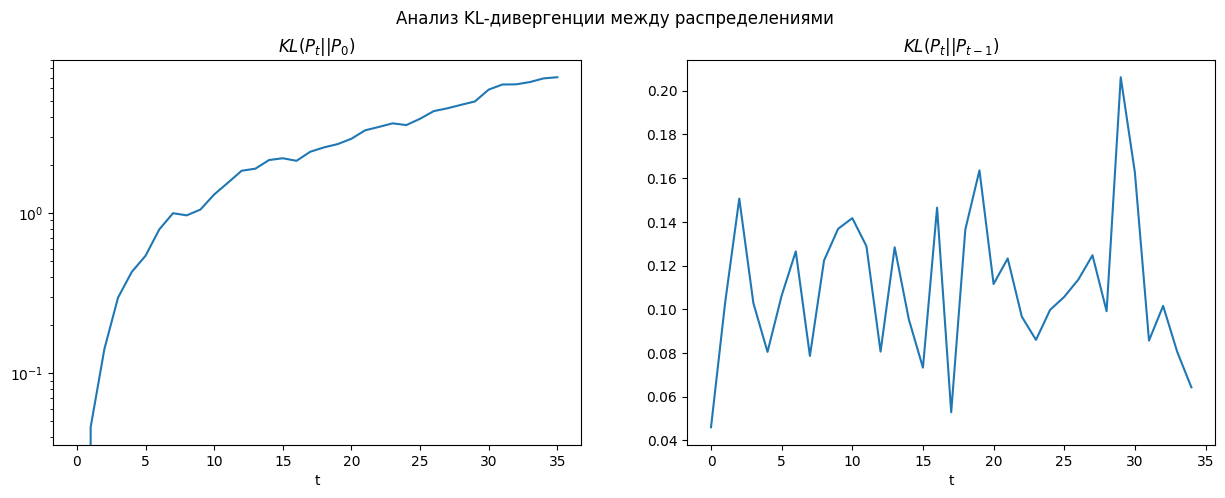

In [ ]:
plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
plt.plot(kl_users)
#plt.yscale('log')
plt.title(r'$KL(P_{t} || P_{0})$')
plt.xlabel('t')


plt.subplot(1, 2, 2)
plt.plot(kl_between_users)
plt.title(r'$KL(P_{t} || P_{t-1})$')
plt.xlabel('t')

plt.suptitle('Анализ KL-дивергенции между распределениями')
plt.show()

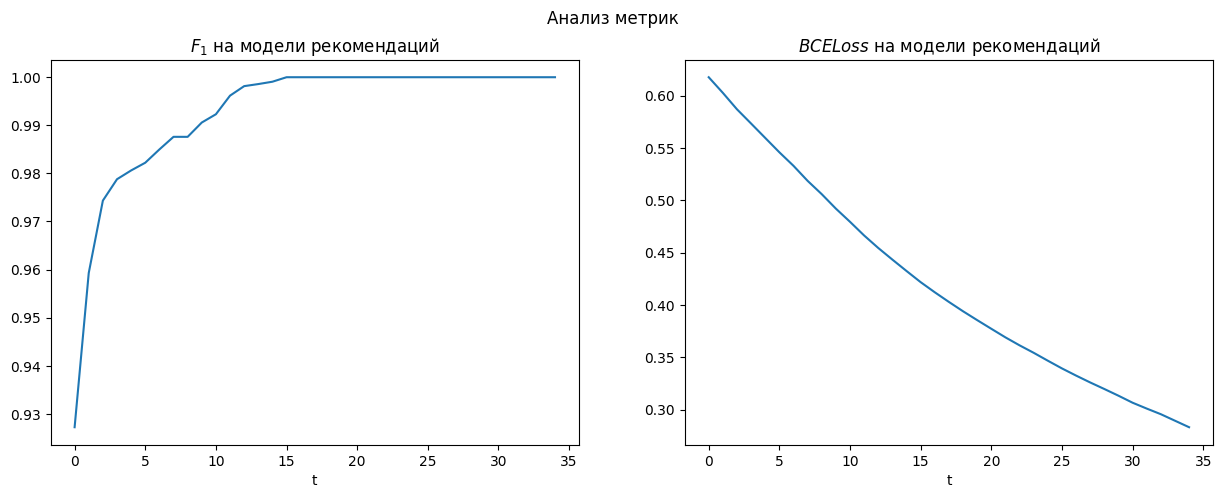

In [ ]:
f1_rec_list = [history['history_rec']['train_f1'] for history in history_list]
loss_rec_list = [history['history_rec']['train_loss'] for history in history_list]

plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
plt.plot(f1_rec_list)
plt.title(r'$F_1 $ на модели рекомендаций')
plt.xlabel('t')


plt.subplot(1, 2, 2)
plt.plot(loss_rec_list)
plt.title(r'$BCELoss$ на модели рекомендаций')
plt.xlabel('t')

plt.suptitle('Анализ метрик')
plt.show()

In [ ]:
arr = np.array([
                [1, 1],
                [1, 2],
                [2, 2],
                [2, 10],
                [11, 31],
                [1, -1]
])

np.cov(arr)

array([[  0. ,   0. ,   0. ,   0. ,   0. ,   0. ],
       [  0. ,   0.5,   0. ,   4. ,  10. ,  -1. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ],
       [  0. ,   4. ,   0. ,  32. ,  80. ,  -8. ],
       [  0. ,  10. ,   0. ,  80. , 200. , -20. ],
       [  0. ,  -1. ,   0. ,  -8. , -20. ,   2. ]])

In [ ]:
item_list = [items_embeddings.copy(), ]
item_loss_list = []
for tau in range(t):
  item_emb = np.load(f'item_emb_{tau}.npy')
  item_list.append(item_emb)
  loss_file = f'item_losses_arr_{tau}.npy'
  item_loss_list.append(np.load(loss_file))

print([x.shape for x in item_list])

[(3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20), (3221, 20)]


In [ ]:
emb_list = [users_embeddings.copy(), ]
user_loss_list = []

for tau in range(t):
  user_emb = np.load(f'user_emb_{tau}.npy')
  emb_list.append(user_emb)
  loss_file = f'user_losses_arr_{tau}.npy'
  user_loss_list.append(np.load(loss_file))

print([x.shape for x in emb_list])

[(66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10), (66, 10)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
all_embeddings = np.concatenate(emb_list, axis=0)

pca = PCA(n_components=2)
pca.fit(all_embeddings)


all_projections = pca.transform(all_embeddings)
x_min, x_max = all_projections[:, 0].min(), all_projections[:, 0].max()
y_min, y_max = all_projections[:, 1].min(), all_projections[:, 1].max()

# 4. Создаем анимацию
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter([], [], alpha=0.6, cmap='viridis') # Добавляем cmap по умолчанию
cbar = fig.colorbar(scatter) # Создаем colorbar
cbar.set_label('Loss') # Подписываем colorbar


def init():
    ax.set_xlim(x_min - 0.1*(x_max-x_min), x_max + 0.1*(x_max-x_min))
    ax.set_ylim(y_min - 0.1*(y_max-y_min), y_max + 0.1*(y_max-y_min))
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_title('Эволюция эмбеддингов с Loss')
    ax.grid(True)
    return scatter, cbar

def update(frame):

    projected = pca.transform(emb_list[frame])
    user_losses = user_loss_list[frame]

    if projected.shape[0] == user_losses.shape[0]:
        scatter.set_offsets(projected)
        scatter.set_array(user_losses)
        scatter.set_clim(vmin=np.min(np.concatenate(user_loss_list)), vmax=np.max(np.concatenate(user_loss_list))) # Фиксируем пределы colorbar
        ax.set_title(f'Шаг {frame+1}/{len(user_loss_list)}')
        return scatter, cbar
    else:
        print(f"Предупреждение: Размеры эмбеддингов и лоссов не совпадают на шаге {frame+1}")
    return scatter, cbar

# Создаем анимацию
ani = FuncAnimation(fig, update, frames=len(user_loss_list),
                    init_func=init, blit=False, interval=1000) # blit=False, так как обновляем цвета

plt.close()
HTML(ani.to_html5_video())

<ipython-input-269-a10278cbfdc4>:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter([], [], alpha=0.6, cmap='viridis') # Добавляем cmap по умолчанию


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Собираем все эмбеддинги из history_list для единого PCA

all_embeddings = np.concatenate(emb_list, axis=0)

# 2. Создаем PCA на всех данных (фиксируем оси)
pca = PCA(n_components=2)
pca.fit(all_embeddings)  # Фитируем на всех данных сразу

# 3. Определяем границы осей (фиксируем масштаб)
all_projections = pca.transform(all_embeddings)
x_min, x_max = all_projections[:, 0].min(), all_projections[:, 0].max()
y_min, y_max = all_projections[:, 1].min(), all_projections[:, 1].max()

# 4. Создаем анимацию
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter([], [], alpha=0.6)

def init():
    ax.set_xlim(x_min - 0.1*(x_max-x_min), x_max + 0.1*(x_max-x_min))
    ax.set_ylim(y_min - 0.1*(y_max-y_min), y_max + 0.1*(y_max-y_min))
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_title('Эволюция эмбеддингов')
    ax.grid(True)
    return scatter,

def update(frame):
    # Проецируем эмбеддинги текущего шага
    projected = pca.transform(emb_list[frame])
    scatter.set_offsets(projected)
    ax.set_title(f'Шаг {frame+1}/{len(emb_list)}')
    return scatter,

# Создаем анимацию
ani = FuncAnimation(fig, update, frames=len(emb_list),
                    init_func=init, blit=True, interval=300)

plt.close()
HTML(ani.to_html5_video())

In [ ]:

# 1. Собираем все эмбеддинги из history_list для единого PCA

all_embeddings = np.concatenate(item_list, axis=0)

# 2. Создаем PCA на всех данных (фиксируем оси)
pca = PCA(n_components=2)
pca.fit(all_embeddings)  # Фитируем на всех данных сразу

# 3. Определяем границы осей (фиксируем масштаб)
all_projections = pca.transform(all_embeddings)
x_min, x_max = all_projections[:, 0].min(), all_projections[:, 0].max()
y_min, y_max = all_projections[:, 1].min(), all_projections[:, 1].max()
#x_min, x_max = -4, 4
#y_min, y_max = -4, 4
# 4. Создаем анимацию
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter([], [], alpha=0.6)

def init():
    ax.set_xlim(x_min - 0.1*(x_max-x_min), x_max + 0.1*(x_max-x_min))
    ax.set_ylim(y_min - 0.1*(y_max-y_min), y_max + 0.1*(y_max-y_min))
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_title('Эволюция эмбеддингов')
    ax.grid(True)
    return scatter,

def update(frame):
    # Проецируем эмбеддинги текущего шага
    projected = pca.transform(item_list[frame])
    scatter.set_offsets(projected)
    ax.set_title(f'Шаг {frame+1}/{len(item_list)}')
    return scatter,

# Создаем анимацию
ani = FuncAnimation(fig, update, frames=len(item_list),
                    init_func=init, blit=True, interval=300)

plt.close()
HTML(ani.to_html5_video())

In [ ]:
print(np.mean(userGAN.distrib_params['cov']))

0.0005897812210637971


In [ ]:
user_emb = dataset.users_embeddings

tsne = TSNE(n_components=2, perplexity=28, random_state=42)
embeddings_2d = tsne.fit_transform(user_emb)
mean_hat = np.mean(user_emb, axis=0)
cov_hat = np.cov(user_emb, rowvar=False)

# Визуализация
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            alpha=0.6, label='Коорд. пользователей')

plt.title("t-SNE визуализация эмбеддингов пользователей")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
history_list

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Загрузка эмбеддингов пользователей
user_emb = dataset.users_embeddings

# Применение PCA для уменьшения размерности до 2D
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(user_emb)

# Вычисление статистик (для справки)
mean_hat = np.mean(user_emb, axis=0)
cov_hat = np.cov(user_emb, rowvar=False)

# Визуализация
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            alpha=0.6, label='Пользовательские эмбеддинги')

# Добавим информацию о дисперсии
plt.title(f"PCA визуализация эмбеддингов пользователей\nОбъясненная дисперсия: {pca.explained_variance_ratio_.sum():.2f}")
plt.xlabel(f"Главная компонента 1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"Главная компонента 2 ({pca.explained_variance_ratio_[1]:.2%})")

plt.legend()
plt.grid(True)
plt.show()

#### отладка кода

In [ ]:
rec_dataset = RecommendationDataset(dataset,
                                    user_embedding_dim=user_embedding_dim_rec,
                                    item_embedding_dim=item_embedding_dim_rec)
choice_dataset = UserBehaviorDataset(dataset,
                                      K=K,
                                      user_embedding_dim=user_embedding_dim_choice,
                                      item_embedding_dim=item_embedding_dim_choice)
print('Датасеты создались')

In [ ]:
#также из обновленного датасета дообучаем алгоритм выбора пользователей
a_rec, history_rec = train_model(a_rec, rec_dataset, num_epoch=1)
a_choice, history_choice = train_model(a_choice, choice_dataset, num_epoch=1)
print('Модели обучились')

In [ ]:
user_transformer = PCA(n_components=user_embedding_dim_rec)
item_transformer = PCA(n_components=item_embedding_dim_rec)
users_embeddings = user_transformer.fit_transform(dataset.users_embeddings.copy())
items_embeddings = item_transformer.fit_transform(dataset.items_embeddings.copy())
recommendations = dict()
user_ids = list(range(len(users_embeddings)))
for user_id in user_ids:
  a_rec.eval()
  user_emb = torch.FloatTensor(users_embeddings[user_id]).to(device)
  items_emb = torch.FloatTensor(items_embeddings).to(device)
  user_emb = (user_emb.expand(items_emb.shape[0], -1)).detach().clone().to(device)
  with torch.no_grad():
    scores = a_rec(user_emb, items_emb)
    top_k_indices = torch.topk(scores, k=K, dim=0).indices.squeeze().cpu().numpy()
  recommendations[user_id] = top_k_indices
print('Рекомендации подобраны')


#моделируем взаимодействие пользователя с topK рекомендациями, предложенными ему
interactions = []
for user_id, item_indices in recommendations.items():
  user_emb = torch.FloatTensor(dataset.users_embeddings[user_id]).to(device).unsqueeze(0)
  items_emb = torch.FloatTensor(dataset.items_embeddings[item_indices]).to(device).unsqueeze(0)
  with torch.no_grad():
      predictions = a_choice(user_emb, items_emb)
      choices = (predictions > 0.6).float().squeeze(0).detach().cpu()

  for item_idx, choice in zip(item_indices, choices):
      if choice == 1:
          interactions.append((user_id, item_idx))

print('Пользователи отреагировали на рекомендации')


### Пост-анализ

In [ ]:
class TopologyTracker:
    def __init__(self):
        self.history = {
            'avg_pairwise_dist': [], # Насколько "широко" распределены пользователи
            'n_clusters': [],        # На сколько кучек они распались
            'inertia': []            # Насколько плотные эти кучки
        }

    def step(self, embeddings):
        """
        embeddings: numpy array (N_users, embedding_dim)
        """
        # 1. Среднее попарное расстояние (мера глобального сжатия)
        # Берем выборку, если пользователей слишком много, для скорости
        sample_size = min(1000, len(embeddings))
        indices = np.random.choice(len(embeddings), sample_size, replace=False)
        sample = embeddings[indices]

        dists = pairwise_distances(sample)
        avg_dist = np.mean(dists)

        # 2. Попытка кластеризации (проверка на поляризацию)
        # Используем KMeans как быстрый способ оценить компактность
        # Допустим, мы ищем 5 крупных центров влияния
        kmeans = KMeans(n_clusters=5, random_state=42, n_init=3).fit(sample)

        self.history['avg_pairwise_dist'].append(avg_dist)
        self.history['n_clusters'].append(len(set(kmeans.labels_))) # Для KMeans константа, но можно использовать DBSCAN
        self.history['inertia'].append(kmeans.inertia_) # Чем меньше, тем плотнее кластеры

        return avg_dist, kmeans.inertia_

tracker = TopologyTracker()


In [ ]:
def get_recommendations_with_noise(model, user_emb, item_emb, unwatched_mask, K=3, epsilon=0.0):
    """
    model: ваша обученная RecModel
    user_emb, item_emb: тензоры эмбеддингов
    unwatched_mask: булева маска (или индексы) непросмотренных товаров
    epsilon: вероятность выдать случайную рекомендацию
    """
    model.eval()
    with torch.no_grad():
        # Ваша логика предсказания скоров (адаптируйте под сигнатуру вашей модели)
        # Предполагаем, что model может принять батч пользователя и всех айтемов
        # Или используем существующий цикл предсказания

        # Упрощенная схема (векторизованная):
        # scores = model(user_emb, item_emb)
        # В вашем коде это может быть цикл. Оставим концептуально:

        # Здесь мы имитируем получение скоров от вашей модели
        # scores = ... (логика из вашей фазы 3)
        pass

    # --- ВАЖНАЯ ЧАСТЬ: ВНЕДРЕНИЕ ШУМА ---
    # Допустим, у нас есть indices_sorted - отсортированные индексы товаров по убыванию скора

    recommendations = []

    # Это псевдокод логики, которую нужно вставить ВНУТРЬ вашего цикла генерации рекомендаций
    # Вместо простого взятия top-K:

    if np.random.random() < epsilon:
        # Случайная рекомендация (Exploration)
        # Берем K случайных индексов из непросмотренных
        random_indices = np.random.choice(unwatched_indices, K, replace=False)
        return random_indices
    else:
        # Жадная рекомендация (Exploitation)
        # Возвращаем то, что предсказала модель
        return top_k_indices


In [ ]:
def run_topology_experiment(
    base_dataset,
    initial_users, initial_items,
    T_steps=50,
    epsilon=0.1,
    K_recs=3
):

    current_users = initial_users.copy()
    current_items = initial_items.copy()


    # userGAN = Generator(..., embeddings=current_users)
    # rec_model = RecModel(...)

    # Трекер для этого эксперимента
    exp_tracker = TopologyTracker()

    metrics_log = {'kl': [], 'f1': []}

    print(f"Запуск эксперимента: Epsilon={epsilon}")

    for t in range(T_steps):
        # --- ФАЗА 1-2: Обучение (как в вашем коде) ---
        # ... (вызов train_model и т.д.)

        # --- ФАЗА 3: Рекомендации с шумом ---
        # Здесь вы интегрируете логику из Ячейки 3
        # Важно: используйте переданный epsilon

        # --- ФАЗА 4-5: Выборы и Обновление матрицы (как в вашем коде) ---

        # --- ФАЗА 6-7: Эволюция (Генераторы) ---
        # userGAN.step(...)
        # Получаем новые current_users

        # --- НОВАЯ ЧАСТЬ: Замер топологии ---
        avg_dist, inertia = exp_tracker.step(current_users)

        # --- Вывод прогресса ---
        if t % 5 == 0:
            print(f"Step {t}: Dist={avg_dist:.4f}, Inertia={inertia:.0f}")

    return exp_tracker.history

# Запуск двух сценариев для сравнения
# 1. "Чистая" эхо-камера (epsilon=0)
history_clean = run_topology_experiment(dataset, users_embeddings, items_embeddings, T_steps=30, epsilon=0.0)

# 2. Сценарий с шумом (epsilon=0.2)
history_noise = run_topology_experiment(dataset, users_embeddings, items_embeddings, T_steps=30, epsilon=0.2)


In [ ]:
plt.figure(figsize=(15, 5))

# График 1: Среднее расстояние (сжатие пространства)
plt.subplot(1, 2, 1)
plt.plot(history_clean['avg_pairwise_dist'], label='Pure Feedback (eps=0)', marker='o')
plt.plot(history_noise['avg_pairwise_dist'], label='With Noise (eps=0.2)', marker='x')
plt.title('Average Pairwise Distance over Time')
plt.xlabel('Time Step')
plt.ylabel('Distance')
plt.legend()
plt.grid(True)

# График 2: Инерция кластеров (формирование плотных групп)
plt.subplot(1, 2, 2)
plt.plot(history_clean['inertia'], label='Pure Feedback (eps=0)', marker='o')
plt.plot(history_noise['inertia'], label='With Noise (eps=0.2)', marker='x')
plt.title('Cluster Inertia (Compactness)')
plt.xlabel('Time Step')
plt.ylabel('Inertia (Lower = Tighter)')
plt.legend()
plt.grid(True)

plt.show()
